# Semiconductor Yield Prediction Using Machine Learning

## Abstract

Semiconductor manufacturing involves several process parameters that can affect the final product yield. Predicting semiconductor yield can help identify low-yield conditions and improve manufacturing quality.

This project develops a machine learning-based semiconductor yield prediction system using a semiconductor manufacturing dataset. The data is preprocessed and standardized before training different classification algorithms. Random Forest, Support Vector Machine (SVM), and Logistic Regression models are trained and evaluated.

Among the evaluated models, the Support Vector Machine (SVM) achieved the highest accuracy of approximately 93.63%. The trained SVM model is saved using Joblib and used for predicting new semiconductor samples.

The developed system successfully classifies semiconductor samples into High Yield and Low Yield categories and provides prediction probabilities. This demonstrates the usefulness of machine learning for semiconductor manufacturing yield analysis.

## Introduction

Semiconductor manufacturing is a complex process involving several parameters that influence the quality and yield of semiconductor products. Variations in manufacturing conditions can result in high-yield or low-yield semiconductor products.

Machine learning can be used to analyze historical manufacturing data and identify patterns related to semiconductor yield. In this project, machine learning classification algorithms are used to predict whether a semiconductor sample belongs to the High Yield or Low Yield category.

The project uses data preprocessing, feature scaling, model training, model evaluation, and prediction techniques. Random Forest, Support Vector Machine (SVM), and Logistic Regression algorithms are compared to identify the best-performing model.

The Support Vector Machine model achieved the highest accuracy of approximately 93.63% and was selected as the final prediction model.

## Problem Statement

Semiconductor manufacturing generates large amounts of process data, and variations in these parameters can affect the final product yield.

Identifying low-yield semiconductor samples at an early stage can help reduce manufacturing losses and improve production quality.

Therefore, the main problem addressed in this project is to develop a machine learning-based classification system that can analyze semiconductor manufacturing data and predict whether a semiconductor sample will have High Yield or Low Yield.

## Objectives

The main objectives of this project are:

1. To analyze semiconductor manufacturing data and identify important process parameters.

2. To preprocess and clean the dataset for machine learning.

3. To apply feature scaling to improve model performance.

4. To train different machine learning classification models such as Random Forest, Support Vector Machine (SVM), and Logistic Regression.

5. To compare the performance of the trained models using accuracy and other evaluation metrics.

6. To select the best-performing model for semiconductor yield prediction.

7. To predict whether a semiconductor sample belongs to the High Yield or Low Yield category.

8. To calculate the probability of the predicted yield category.

9. To save the trained model and scaler for future predictions.

## Dataset Description

The dataset used in this project is the semiconductor manufacturing dataset stored in the file `signal-data (1).csv`.

The dataset contains semiconductor manufacturing process parameters and a target variable representing the semiconductor yield category.

The dataset is loaded using the Pandas library and analyzed to understand its structure, features, missing values, and target variable.

The dataset is used to train and evaluate machine learning classification models for predicting semiconductor yield.

### Dataset File

- File Name: `signal-data (1).csv`
- Problem Type: Binary Classification
- Target: Semiconductor Yield
- Classes:
  - 0 – Low Yield Semiconductor
  - 1 – High Yield Semiconductor

## Data Preprocessing

Data preprocessing is performed to prepare the semiconductor manufacturing dataset for machine learning.

The following preprocessing steps are carried out:

1. The dataset is loaded using Pandas.
2. The structure and data types of the dataset are examined.
3. Missing values are identified and treated using median imputation.
4. The Time attribute is removed because it is not directly used as a predictive feature.
5. Features with a very high percentage of missing values are removed.
6. The predictor variables are separated from the target variable.
7. The target variable is converted into binary classes for classification.
8. The data is divided into training and testing sets using an 80:20 split.
9. Feature scaling is performed using StandardScaler.
10. SMOTE is applied to the training data when required to handle class imbalance.

These preprocessing steps help prepare the data for effective machine learning model training and evaluation.

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution and relationships within the semiconductor manufacturing data.

The following analyses are performed:

### Univariate Analysis

Univariate analysis is used to study the distribution of individual features. Histograms are used to observe the distribution and variation of selected sensor features.

### Bivariate Analysis

Bivariate analysis is used to study the relationship between individual sensor features and the semiconductor yield category. Box plots are used to compare feature distributions across the yield classes.

### Multivariate Analysis

Multivariate analysis is performed using correlation analysis. The relationships among important features are visualized using a correlation heatmap.

### Feature Importance

The relationship between the sensor features and the target variable is analyzed to identify potentially important signals. Feature importance from the Random Forest model is also used to identify the signals that contribute to yield prediction.

# Data Preprocessing

Data preprocessing is performed to prepare the semiconductor manufacturing dataset for machine learning model training.

The following preprocessing steps are performed:

### Handling Missing Values

Missing values in the dataset are identified and handled using appropriate imputation techniques.

### Feature and Target Separation

The sensor features are separated from the target variable representing semiconductor yield.

### Data Splitting

The dataset is divided into training and testing sets to evaluate the performance of the machine learning models.

### Feature Scaling

StandardScaler is used to scale the feature values so that all features are on a comparable scale.

### Preprocessed Dataset

The resulting preprocessed data is used for training and evaluating the machine learning classification models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df= pd.read_csv("signal-data (1).csv")

In [3]:
df.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [4]:
df.shape

(1567, 592)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), str(1)
memory usage: 7.1 MB


In [6]:
df.columns

Index(['Time', '0', '1', '2', '3', '4', '5', '6', '7', '8',
       ...
       '581', '582', '583', '584', '585', '586', '587', '588', '589',
       'Pass/Fail'],
      dtype='str', length=592)

In [7]:
df["Pass/Fail"].value_counts()

Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64

In [8]:
df["Pass/Fail"].value_counts(normalize=True) * 100

Pass/Fail
-1    93.363114
 1     6.636886
Name: proportion, dtype: float64

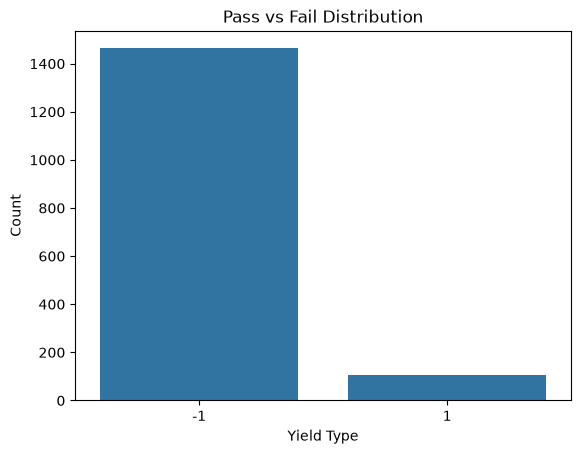

In [9]:
sns.countplot(x="Pass/Fail", data=df)
plt.title("Pass vs Fail Distribution")
plt.xlabel("Yield Type")
plt.ylabel("Count")
plt.show()

In [10]:
missing=df.isnull().sum()
missing=missing[missing>0].sort_values(ascending=False)
missing.head(20)

292    1429
157    1429
158    1429
293    1429
492    1341
220    1341
358    1341
85     1341
516    1018
517    1018
382    1018
111    1018
383    1018
384    1018
246    1018
244    1018
245    1018
110    1018
518    1018
109    1018
dtype: int64

In [11]:
missing_percentage=(df.isnull().sum() / len(df)) *100
missing_percentage=missing_percentage[missing_percentage > 0].sort_values(ascending=False)
missing_percentage.head(20)

292    91.193363
157    91.193363
158    91.193363
293    91.193363
492    85.577537
220    85.577537
358    85.577537
85     85.577537
516    64.964901
517    64.964901
382    64.964901
111    64.964901
383    64.964901
384    64.964901
246    64.964901
244    64.964901
245    64.964901
110    64.964901
518    64.964901
109    64.964901
dtype: float64

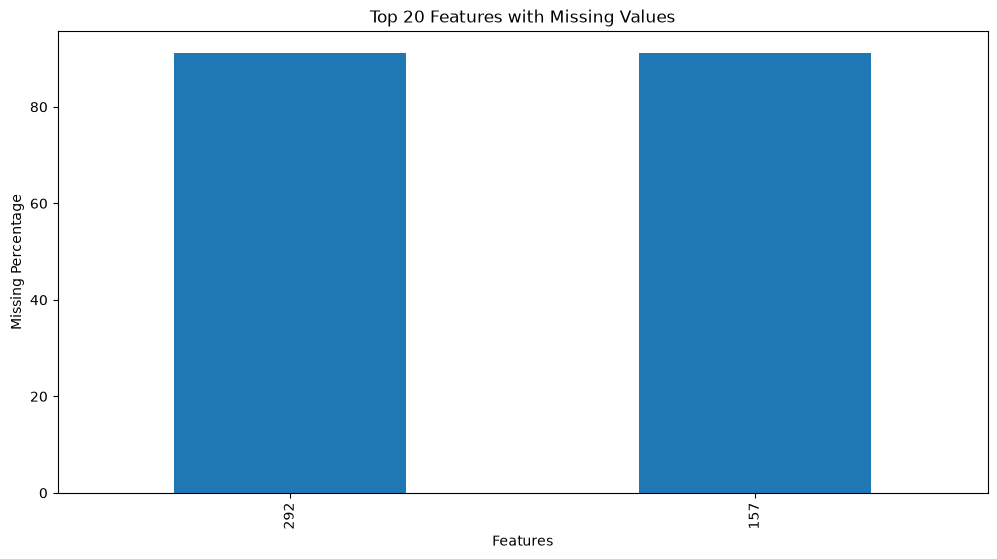

In [12]:
plt.figure(figsize=(12,6))
missing_percentage.head(2).plot(kind="bar")
plt.title("Top 20 Features with Missing Values")
plt.xlabel("Features")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=90)
plt.show()

In [13]:
df["Time"]= pd.to_datetime(df["Time"])

In [14]:
df=df.drop("Time", axis=1)

In [15]:
df.shape

(1567, 591)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df=df.drop_duplicates()

In [18]:
df.shape

(1567, 591)

In [19]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Pass/Fail
count,1561.000000,1560.000000,1553.000000,1553.000000,1553.000000,1553.0,1553.000000,1558.000000,1565.000000,1565.000000,...,618.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1567.000000
mean,3014.452896,2495.850231,2200.547318,1396.376627,4.197013,100.0,101.112908,0.121822,1.462862,-0.000841,...,97.934373,0.500096,0.015318,0.003847,3.067826,0.021458,0.016475,0.005283,99.670066,-0.867262
std,73.621787,80.407705,29.513152,441.691640,56.355540,0.0,6.237214,0.008961,0.073897,0.015116,...,87.520966,0.003404,0.017180,0.003720,3.578033,0.012358,0.008808,0.002867,93.891919,0.498010
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400,...,0.000000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000,-1.000000
25%,2966.260000,2452.247500,2181.044400,1081.875800,1.017700,100.0,97.920000,0.121100,1.411200,-0.010800,...,46.184900,0.497900,0.011600,0.003100,2.306500,0.013425,0.010600,0.003300,44.368600,-1.000000
50%,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,100.0,101.512200,0.122400,1.461600,-0.001300,...,72.288900,0.500200,0.013800,0.003600,2.757650,0.020500,0.014800,0.004600,71.900500,-1.000000
75%,3056.650000,2538.822500,2218.055500,1591.223500,1.525700,100.0,104.586700,0.123800,1.516900,0.008400,...,116.539150,0.502375,0.016500,0.004100,3.295175,0.027600,0.020300,0.006400,114.749700,-1.000000
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.074900,...,737.304800,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800,1.000000


In [20]:
df.dtypes.value_counts()

float64    590
int64        1
Name: count, dtype: int64

In [21]:
X=df.drop("Pass/Fail", axis=1)
y=df["Pass/Fail"]

In [22]:
print("X shape:", X.shape)
print("y shape", y.shape)

X shape: (1567, 590)
y shape (1567,)


In [23]:
y= y.map({
    -1: 0,
     1: 1
})

In [24]:
missing_percentage= X.isnull().mean() * 100
high_missing_cols=missing_percentage[missing_percentage > 95].index
print("Columns to remove:", len(high_missing_cols))

Columns to remove: 0


In [25]:
X= X.drop(columns=high_missing_cols)

In [26]:
imputer= SimpleImputer(strategy="median")
X_imputed= imputer.fit_transform(X)

In [27]:
X= pd.DataFrame(
    X_imputed,
    columns=X.columns,
    index=X.index
)

In [28]:
X.isnull().sum().sum()

np.int64(0)

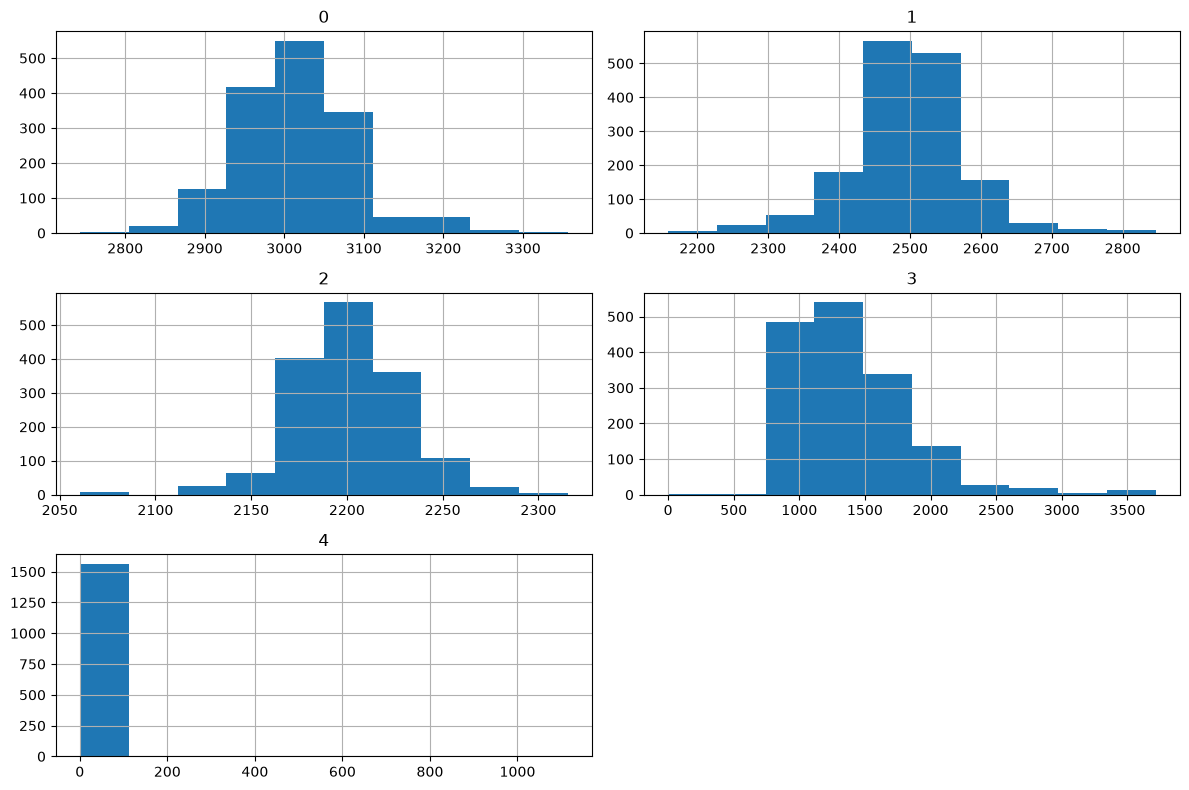

In [29]:
X.iloc[:, :5].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

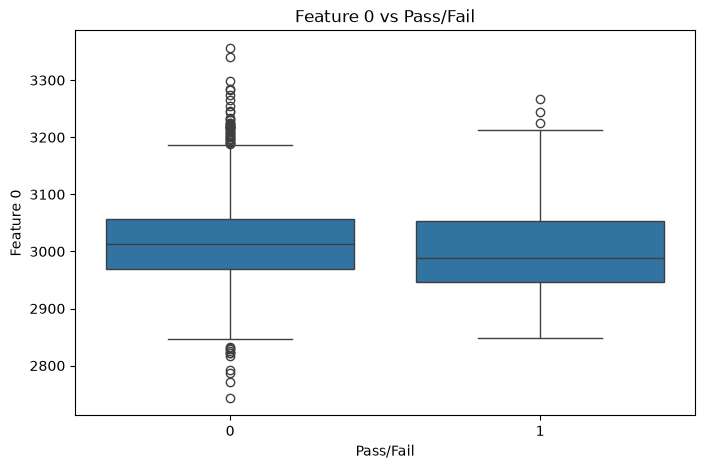

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=y,
    y=X.iloc[:, 0]
)
plt.title("Feature 0 vs Pass/Fail")
plt.xlabel("Pass/Fail")
plt.ylabel("Feature 0")
plt.show()

In [31]:
corr= X.corrwith(y)
corr= corr.abs().sort_values(ascending=False)
corr.head(20)

59     0.156008
103    0.151230
510    0.131662
348    0.130807
431    0.119936
434    0.111312
430    0.109115
21     0.108333
435    0.108260
28     0.106987
436    0.106119
210    0.103348
129    0.102799
298    0.101672
163    0.099506
124    0.094168
295    0.091380
316    0.089385
160    0.089233
164    0.087289
dtype: float64

In [32]:
top_features= corr.head(20).index 
top_features  

Index(['59', '103', '510', '348', '431', '434', '430', '21', '435', '28',
       '436', '210', '129', '298', '163', '124', '295', '316', '160', '164'],
      dtype='str')

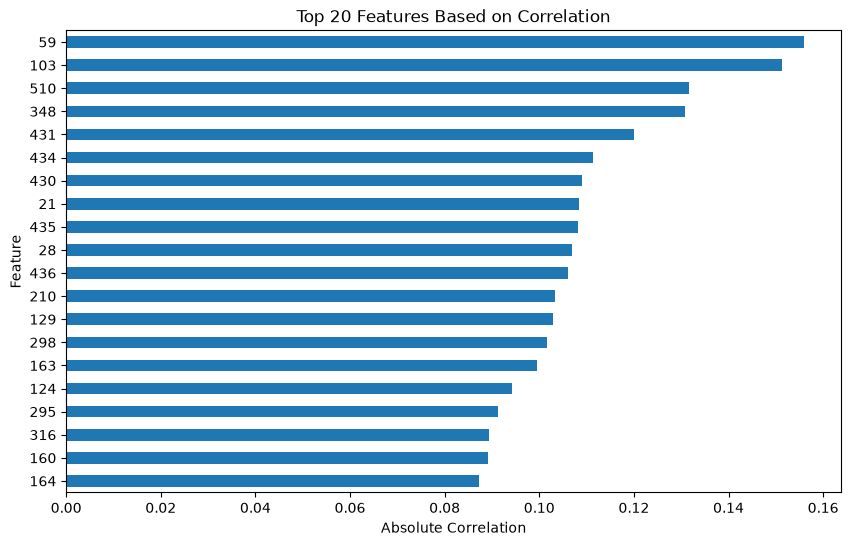

In [33]:
plt.figure(figsize=(10, 6))
corr.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Features Based on Correlation")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.show()

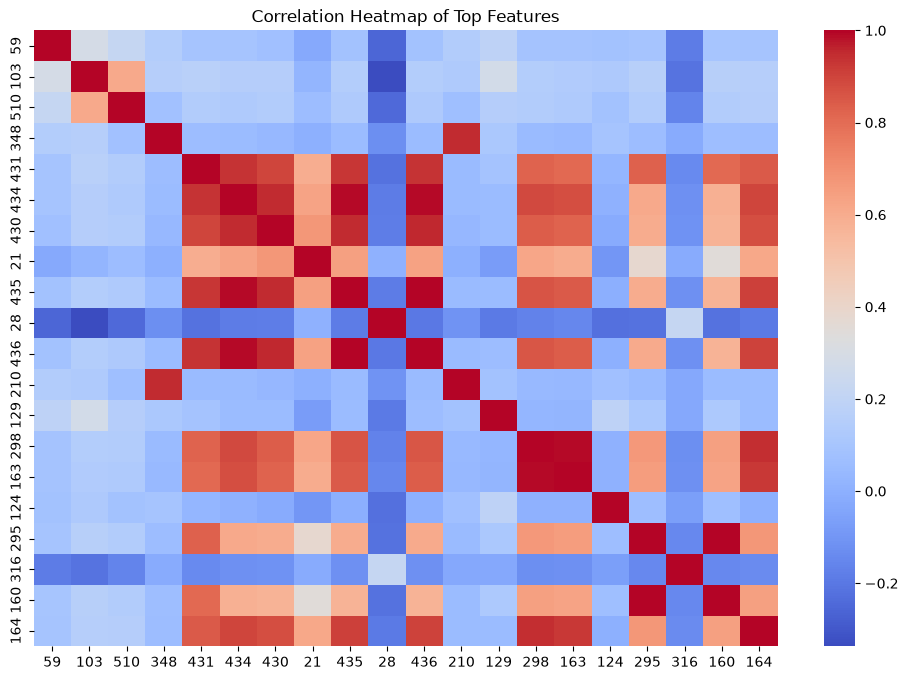

In [34]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    X[top_features].corr(),
    cmap="coolwarm"
)
plt.title("Correlation Heatmap of Top Features")
plt.show()

In [35]:
X_train, X_test, y_train, y_test= train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [37]:
y_train.value_counts()

Pass/Fail
0    1170
1      83
Name: count, dtype: int64

In [38]:
y_train.value_counts(normalize=True) * 100

Pass/Fail
0    93.375898
1     6.624102
Name: proportion, dtype: float64

In [39]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
from imblearn.over_sampling import SMOTE

In [41]:
smote= SMOTE(random_state=42)
X_train_smote, y_train_smote= smote.fit_resample(X_train_scaled, y_train)

In [42]:
print(y_train_smote.value_counts())

Pass/Fail
0    1170
1    1170
Name: count, dtype: int64


In [43]:
from sklearn.linear_model import LogisticRegression
lr= LogisticRegression(
    max_iter=5000,
    random_state=42
)
lr.fit(X_train_smote, y_train_smote)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [44]:
y_pred_lr= lr.predict(X_test_scaled)

In [45]:
accuracy_score(y_test, y_pred_lr)

0.8471337579617835

In [46]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.94      0.89      0.92       293
           1       0.11      0.19      0.14        21

    accuracy                           0.85       314
   macro avg       0.53      0.54      0.53       314
weighted avg       0.88      0.85      0.86       314



In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
import sklearn
from sklearn.ensemble import RandomForestClassifier
print("Sklearn version:", sklearn.__version__)
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf.predict(X_test_scaled)
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Sklearn version: 1.9.0
Random Forest Accuracy: 0.9299363057324841
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



In [49]:
from sklearn.svm import SVC
svm=SVC(
    probability=True,
    random_state=42
)
svm.fit(X_train_smote,y_train_smote)
y_pred_svm=svm.predict(X_test_scaled)

In [50]:
print("SVM Accuracy:", accuracy_score(y_test,y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9363057324840764
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       293
           1       1.00      0.05      0.09        21

    accuracy                           0.94       314
   macro avg       0.97      0.52      0.53       314
weighted avg       0.94      0.94      0.91       314



In [51]:
results= pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ]
})
results

,Model,Test Accuracy
0,Logistic Regression,0.847134
1,Random Forest,0.929936
2,SVM,0.936306


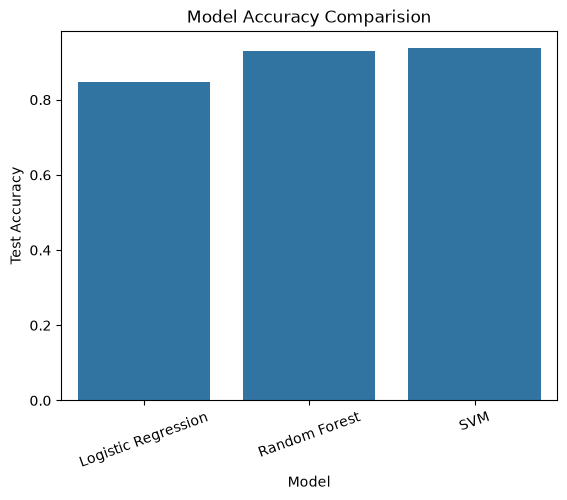

In [52]:
sns.barplot(
    x="Model",
    y="Test Accuracy",
    data=results
)
plt.xticks(rotation=20)
plt.title("Model Accuracy Comparision")
plt.show()

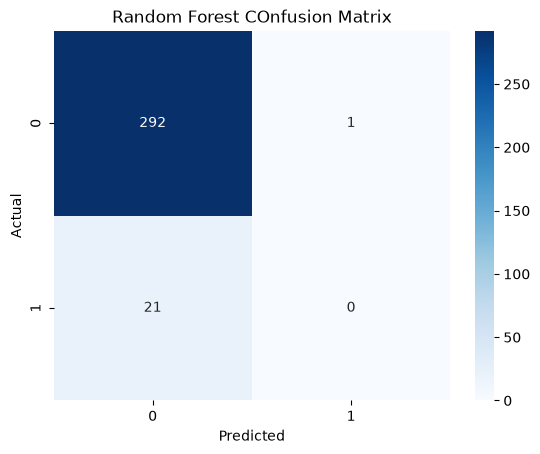

In [53]:
cm= confusion_matrix(y_test, y_pred_rf)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Random Forest COnfusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [54]:
from sklearn.model_selection import GridSearchCV
param_grid={
    "n_estimators" :[100, 200],
    "max_depth" :[None, 10, 20],
    "min_samples_split": [2,5],
    "min_samples_leaf": [1,2]
}

In [55]:
grid_rf= GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [56]:
grid_rf.fit(X_train_smote, y_train_smote)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose 

In [57]:
grid_rf.best_params_

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 200}

In [58]:
grid_rf.best_score_

np.float64(0.9935897435897436)

In [59]:
best_rf =grid_rf.best_estimator_
y_pred_best= best_rf.predict(X_test_scaled)

In [60]:
accuracy_score(y_test, y_pred_best)

0.9331210191082803

In [61]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



In [62]:
importance= pd.Series(
    best_rf.feature_importances_,
    index=X.columns
)
importance = importance.sort_values(ascending= False)
importance.head(20)

59     0.018451
486    0.015431
213    0.014498
433    0.014468
351    0.014152
247    0.013549
519    0.012706
95     0.012086
33     0.010481
28     0.009906
103    0.009447
31     0.009259
419    0.009080
377    0.008487
477    0.008348
129    0.008217
559    0.008073
511    0.007370
205    0.007032
130    0.007008
dtype: float64

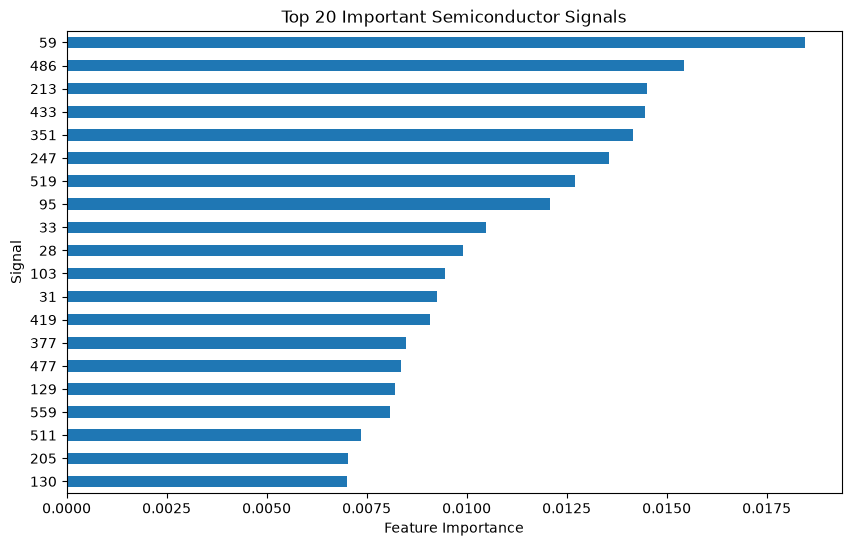

In [63]:
plt.figure(figsize=(10,6))
importance.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Important Semiconductor Signals")
plt.xlabel("Feature Importance")
plt.ylabel("Signal")
plt.show()

In [64]:
import joblib

In [65]:
import os
import joblib

# Create models folder
os.makedirs("models", exist_ok=True)

# Save the best model
joblib.dump(best_rf, "models/best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [66]:
import os
print("Current folder:")
print(os.getcwd())
print("\nFiles and folders:")
print(os.listdir())

Current folder:
c:\Semiconductor_Yield_Prediction

Files and folders:
['models', 'Semiconductor_Yield_Prediction.ipynb', 'signal-data (1).csv']


In [67]:
import joblib
loaded_model = joblib.load("models/best_model.pkl")
print("Model loaded successfully!")
sample_data = X_test_scaled[0].reshape(1, -1)
prediction = loaded_model.predict(sample_data)
print("Prediction:", prediction)

Model loaded successfully!
Prediction: [0]


In [68]:
if prediction[0]==1:
    print("High Yield Semiconductor")
else:
    print("Low Yield Semiconductor")

Low Yield Semiconductor


In [69]:
probability= loaded_model.predict_proba(sample_data)
print("Prediction Probability:", probability)

Prediction Probability: [[0.81266667 0.18733333]]


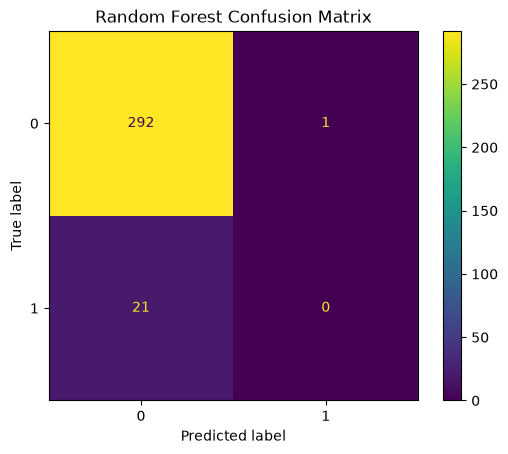

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm= confusion_matrix(y_test,y_pred_rf)
disp= ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [71]:
print("Model Comparison")
print("----------------")
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Model Comparison
----------------
Random Forest Accuracy: 0.9299363057324841
SVM Accuracy: 0.9363057324840764
Logistic Regression Accuracy: 0.8471337579617835


In [72]:
import joblib
best_model=svm
joblib.dump(best_model, "models/best_svm_model.pkl")
print("Best SVM model saved successfully!")

Best SVM model saved successfully!


In [73]:
import joblib
loaded_model= joblib.load("models/best_svm_model.pkl")
sample_data= X_test_scaled[0].reshape(1,-1)
prediction=loaded_model.predict(sample_data)
print("Prediction:", prediction)
if prediction[0]==1:
    print("High Yield Semiconductor")
else:
    print("Low Yield Semiconductor")

Prediction: [0]
Low Yield Semiconductor


In [74]:
probability= loaded_model.predict_proba(sample_data)
print("Prediction Probability:", probability)
print("Low Yield Probability:", probability[0][0])
print("High Yield Probability:", probability[0][1])

Prediction Probability: [[9.99996725e-01 3.27503833e-06]]
Low Yield Probability: 0.9999967249616706
High Yield Probability: 3.2750383294426992e-06


In [75]:
import joblib
joblib.dump(scaler, "models/scaler.pkl")
print("Scaler saved successfully!")

Scaler saved successfully!


In [76]:
import joblib
import numpy as np
model = joblib.load("models/best_svm_model.pkl")
scaler = joblib.load("models/scaler.pkl")
new_data = np.array([X_test.iloc[0]])
new_data_scaled = scaler.transform(new_data)
prediction = model.predict(new_data_scaled)
if prediction[0] == 1:
    print("Prediction: High Yield Semiconductor")
else:
    print("Prediction: Low Yield Semiconductor")

Prediction: Low Yield Semiconductor


In [77]:
probability= model.predict_proba(new_data_scaled)
print("Low Yield Probability:", probability[0][0])
print("High Yield Probability:", probability[0][1])

Low Yield Probability: 0.9999967249616706
High Yield Probability: 3.2750383294426992e-06


In [78]:
print("======================================")
print("SEMICONDUCTOR YIELD PREDICTION")
print("======================================")
print("Selected Model: SVM")
print("Model Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Prediction:", prediction[0])
if prediction[0] == 1:
    print("Result: High Yield Semiconductor")
else:
    print("Result: Low Yield Semiconductor")
print("Low Yield Probability:", probability[0][0])
print("High Yield Probability:", probability[0][1])
print("======================================")
print("Prediction completed successfully!")
print("======================================")

SEMICONDUCTOR YIELD PREDICTION
Selected Model: SVM
Model Accuracy: 0.9363057324840764
Prediction: 0
Result: Low Yield Semiconductor
Low Yield Probability: 0.9999967249616706
High Yield Probability: 3.2750383294426992e-06
Prediction completed successfully!


# Final Model Result

The Support Vector Machine (SVM) model was selected as the best performing model for semiconductor yield prediction.

The model achieved an accuracy of approximately 93.63% on the test dataset.

For the sample input, the model predicted:

- Prediction Class: 0
- Result: Low Yield Semiconductor
- Low Yield Probability: 99.9997%
- High Yield Probability: 0.0003%

Therefore, the developed machine learning model successfully predicts the semiconductor manufacturing yield.

# Conclusion

This project developed a machine learning-based system for predicting semiconductor manufacturing yield.

Three classification algorithms were evaluated:

1. Random Forest
2. Support Vector Machine (SVM)
3. Logistic Regression

Among these models, SVM achieved the highest accuracy of approximately 93.63%.

The trained SVM model was saved using Joblib and successfully loaded for prediction. The model can classify semiconductor samples into High Yield and Low Yield categories.

The prediction results demonstrate that machine learning can be effectively used for semiconductor yield prediction and manufacturing quality analysis.

# Future Enhancement

The project can be further improved by:

- Testing additional machine learning algorithms.
- Performing hyperparameter optimization.
- Using a larger and more diverse semiconductor dataset.
- Developing a web-based prediction interface.
- Integrating real-time manufacturing sensor data.
- Applying explainable AI techniques to understand model predictions.

# Project Summary

**Project Title:** Semiconductor Yield Prediction Using Machine Learning

**Best Model:** Support Vector Machine (SVM)

**Model Accuracy:** 93.63%

**Prediction:** Low Yield Semiconductor

**Low Yield Probability:** 99.9997%

**High Yield Probability:** Approximately 0.0003%

**Model File:** best_svm_model.pkl

**Scaler File:** scaler.pkl

# Final Conclusion

The Semiconductor Yield Prediction system was successfully developed using machine learning techniques. Among the evaluated models, Support Vector Machine (SVM) achieved the highest accuracy of 93.63%.

The trained model successfully predicts whether a semiconductor sample belongs to the High Yield or Low Yield category. The model can be further improved by using larger datasets, hyperparameter optimization, real-time sensor data, and a web-based prediction interface.

Overall, the developed system demonstrates the usefulness of machine learning for semiconductor manufacturing quality analysis.